# PyCBC chi-square: separate the numerical effects

**PyCBC 2.11.0 still exhibits the complex64 discrepancy.** Keep the exact one-coefficient reproduction, then isolate phase precision, π, accumulation, and index casting in small experiments. The [real-data notebook](cpu_chisq_real_data.ipynb) tests multiplication rounding and all combinations on captured H1 inputs.

**Run:** `python -m pip install "pycbc==2.11.0" matplotlib jupyterlab`, then **Restart Kernel and Run All**. This is the latest stable [PyPI release](https://pypi.org/project/PyCBC/2.11.0/) checked on 21 September 2026. Internet is needed only if the shared helper is not beside the notebook. Low-order results may vary by machine.

In [1]:
import platform
import warnings

# Silence only LAL's unrelated notebook-output performance notice.
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import numpy as np
import pycbc
from pycbc.types import Array
from pycbc.scheme import CPUScheme
from pycbc.vetoes.chisq_cpu import shift_sum

print(f"PyCBC {pycbc.__version__}; NumPy {np.__version__}; "
      f"Python {platform.python_version()}; {platform.system()} {platform.machine()}")
assert pycbc.__version__ == '2.11.0'

PyCBC 2.11.0; NumPy 2.3.5; Python 3.13.9; Darwin arm64


## 1. The installed CPU routine: exact answer = 1

One frequency coefficient is 1; all others are zero. A phase rotation must preserve its power. **S = Σ|qᵦ|² = 1** for either input precision. This proves a power error; it does not isolate its angular component.

In [2]:
N = 2**20
sample = 100_000
bins = [0, N // 4, N // 2]       # Two equal-width frequency bins.
k = bins[1] - 1                 # Last coefficient of the first bin.
corr = np.zeros(N, dtype=np.complex64)
corr[k] = 1

print(f"{'input':<12} {'output':<10} {'S (expected 1)':>20} {'error (%)':>14}")
powers = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        result = shift_sum(Array(corr.astype(dtype)), [sample], bins)
        powers[np.dtype(dtype).name] = float(result[0])
        print(f"{np.dtype(dtype).name:<12} {str(result.dtype):<10} "
              f"{result[0]:20.13f} {100 * (float(result[0]) - 1):14.8g}")

    # Controls: no rotation, and double-precision rotation.
    np.testing.assert_array_equal(shift_sum(Array(corr), [0], bins), [1.0])
np.testing.assert_allclose(powers['complex128'], 1.0, rtol=0, atol=1e-8)

input        output           S (expected 1)      error (%)
complex64    float32         1.0109626054764      1.0962605
complex128   float64         1.0000000000025  2.4551472e-10


## 2. Phase precision and π, separately and together

Move a single unit-valued coefficient through a bin and inspect its phase. Four model curves cross float32/float64 phase storage and updates with truncated/full π. The lower panel measures angular error independently of magnitude. Black dots in the upper panel are fresh installed-PyCBC bin-power calls.

The [99-line shared model](https://github.com/xangma/pycbc/blob/4e06fff52a7181f9cb3e8ffffe5b7a3866827a11/examples/numerics/chisq_error_controls.py) is bundled or downloaded with a pinned hash. It implements explicit arithmetic controls in NumPy; it is **not a modified PyCBC binary**. Compiler contraction and library arithmetic can differ. No JAX or new compiled extension is needed.

In [3]:
from pathlib import Path
from urllib.request import urlopen
import hashlib
import matplotlib.pyplot as plt

# A small, inspectable NumPy model shared by both notebooks; no compiler needed.
helper_name = 'chisq_error_controls.py'
helper_commit = '4e06fff52a7181f9cb3e8ffffe5b7a3866827a11'
helper_sha = 'e582bdbca7184ac59fe96d4058c03d59a4123056a34ce705a397c0a0a1a98954'
local = next((p for p in [Path(helper_name), Path('examples/numerics') / helper_name]
              if p.is_file()), None)
if local is not None:
    source = local.read_bytes()
else:
    url = f'https://raw.githubusercontent.com/xangma/pycbc/{helper_commit}/examples/numerics/{helper_name}'
    with urlopen(url, timeout=60) as response:
        source = response.read()
assert hashlib.sha256(source).hexdigest() == helper_sha
exec(compile(source, helper_name, 'exec'))
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'lines.linewidth': 1.7})


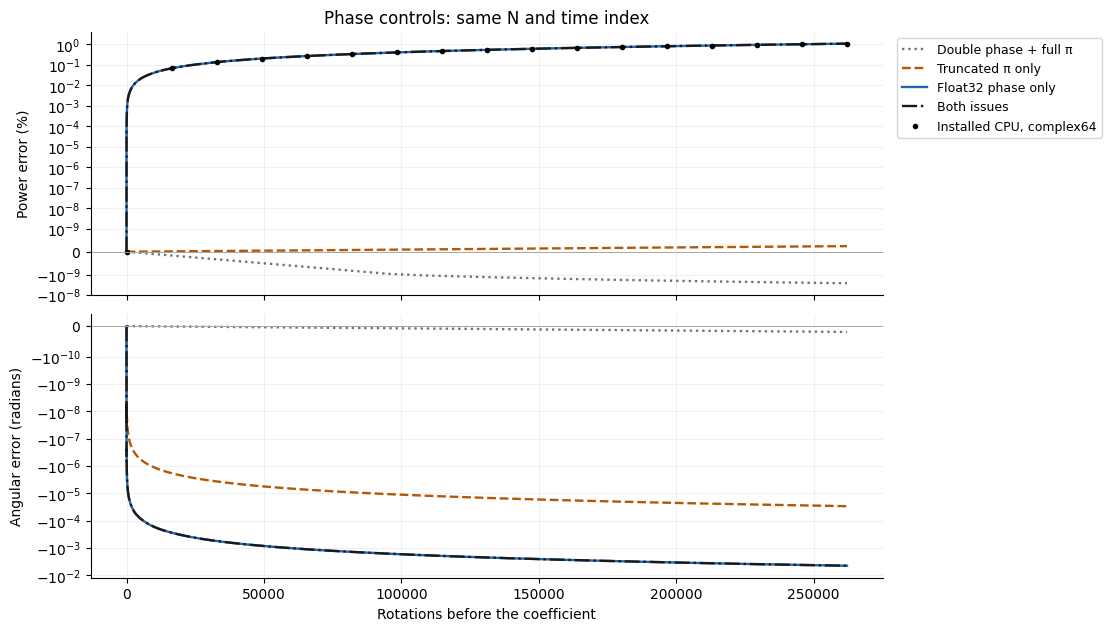

Truncated π alone: measured -2.9489538e-05 rad; analytic prediction -2.9489543e-05 rad


In [4]:
positions = np.unique(np.r_[0, np.geomspace(1, k, 100).astype(int)])
reference_phase = np.exp(2j * np.pi * ((positions.astype(np.int64) * sample) % N) / N)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True, layout='constrained')
phase_results = {}
for single, short_pi, label, color, style in [
    (False, False, 'Double phase + full π', '0.45', ':'),
    (False, True, 'Truncated π only', COLORS[1], '--'),
    (True, False, 'Float32 phase only', COLORS[2], '-'),
    (True, True, 'Both issues', '0.1', '-.')]:
    phase = phases(N, sample, 0, k+1, single, short_pi)[positions].astype(np.complex128)
    power_error = 100 * (np.abs(phase)**2 - 1)
    angle_error = np.angle(phase / reference_phase)
    phase_results[label] = (power_error, angle_error)
    axes[0].plot(positions, power_error, color=color, ls=style, label=label)
    axes[1].plot(positions, angle_error, color=color, ls=style)

actual_positions = np.linspace(0, k, 17, dtype=int)
with CPUScheme():
    probe = Array(np.zeros(N, dtype=np.complex64))
    actual_power = []
    for position in actual_positions:
        probe[position] = 1
        actual_power.append(float(shift_sum(probe, [sample], bins)[0]))
        probe[position] = 0
axes[0].plot(actual_positions, 100*(np.array(actual_power)-1), 'o', ms=3,
             color='black', label='Installed CPU, complex64')
axes[0].set(yscale='symlog', ylabel='Power error (%)', title='Phase controls: same N and time index')
axes[0].set_yscale('symlog', linthresh=1e-9)
axes[1].set_yscale('symlog', linthresh=1e-10)
axes[1].set(ylabel='Angular error (radians)', xlabel='Rotations before the coefficient')
for ax in axes:
    ax.axhline(0, color='0.65', lw=0.7)
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
axes[0].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()
# The truncated-pi bias has an independent analytic prediction.
predicted_bias = 2 * (3.141592653 - np.pi) * sample * k / N
np.testing.assert_allclose(phase_results['Truncated π only'][1][-1], predicted_bias,
                           rtol=0, atol=1e-9)
print(f'Truncated π alone: measured {phase_results["Truncated π only"][1][-1]:.8g} rad; '
      f'analytic prediction {predicted_bias:.8g} rad')


## 3. Accumulation and index casting: independent probes

**Accumulation:** use time index 0, so every phase is exactly 1 regardless of π. Terms are exactly representable: one 1 followed by 2⁻²⁶. The exact running sum is known; installed PyCBC verifies both endpoints.

**Index casting:** a separate synthetic boundary case uses N = 2²⁶ and times near 2²⁴. Keep full π, double arithmetic and no recurrence; change only the float32 cast of the time index. For coefficients at 0 and N/4, exact modular phases give the bin power. No large array is allocated. **This issue is absent from the H1 capture.**

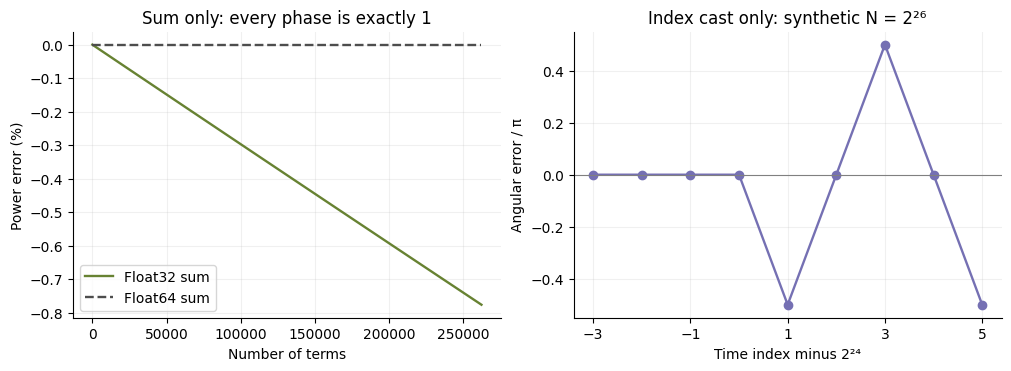

Accumulation-only endpoint: {'complex64': 1.0, 'complex128': 1.007827728870325} ; exact power: 1.007827728870325
Index 16777217 becomes 16777216: two-coefficient power 2 becomes 4


In [5]:
length = 2**18
values = np.full(length, 2.0**-26, dtype=np.float32)
values[0] = 1
counts = np.unique(np.r_[1, np.geomspace(2, length, 100).astype(int)])
exact_power = (1 + (counts-1) * 2.0**-26)**2
sum32_power = np.cumsum(values, dtype=np.float32)[counts-1].astype(np.float64)**2
sum64_power = np.cumsum(values, dtype=np.float64)[counts-1]**2
with CPUScheme():
    cpu_sum = {np.dtype(dt).name: float(shift_sum(Array(values.astype(dt)), [0], [0, length])[0])
               for dt in [np.complex64, np.complex128]}
assert cpu_sum['complex64'] == 1.0
np.testing.assert_allclose(cpu_sum['complex128'], exact_power[-1], rtol=0, atol=1e-14)

large_N, frequency = 2**26, 2**24
indices = 2**24 + np.arange(-3, 6, dtype=np.int64)
rounded_indices = indices.astype(np.float32).astype(np.int64)
exact_phase = np.exp(2j*np.pi*((frequency*indices) % large_N)/large_N)
cast_phase = np.exp(2j*np.pi*((frequency*rounded_indices) % large_N)/large_N)
angle_error = np.angle(cast_phase / exact_phase)
row = int(np.flatnonzero(indices == 2**24+1)[0])
np.testing.assert_allclose(angle_error[row], -np.pi/2, rtol=0, atol=1e-14)
exact_two_term_power, cast_two_term_power = abs(1+exact_phase[row])**2, abs(1+cast_phase[row])**2
np.testing.assert_allclose([exact_two_term_power, cast_two_term_power], [2, 4], atol=1e-14)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout='constrained')
for power, label, color, style in [(sum32_power, 'Float32 sum', COLORS[8], '-'),
                                    (sum64_power, 'Float64 sum', '0.3', '--')]:
    axes[0].plot(counts, 100*(power/exact_power-1), color=color, ls=style, label=label)
axes[0].set(xlabel='Number of terms', ylabel='Power error (%)', title='Sum only: every phase is exactly 1')
axes[0].legend()
axes[1].plot(indices-2**24, angle_error/np.pi, 'o-', color='#7570b3')
axes[1].axhline(0, color='0.5', lw=0.8)
axes[1].set(xlabel='Time index minus 2²⁴', ylabel='Angular error / π',
            title='Index cast only: synthetic N = 2²⁶', xticks=[-3, -1, 1, 3, 5])
plt.show()
print('Accumulation-only endpoint:', cpu_sum, '; exact power:', exact_power[-1])
print(f'Index {indices[row]} becomes {rounded_indices[row]}: '
      f'two-coefficient power {exact_two_term_power:g} becomes {cast_two_term_power:g}')


## 4. Original chi-square check

For the one-coefficient example, two bins and |snr|² = 1 give **χ² = 2S − 1 = 1**. This preserves the original minimal reproduction.

In [6]:
from pycbc.vetoes.chisq import power_chisq_at_points_from_precomputed

snr = np.array([np.exp(2j * np.pi * ((k * sample) % N) / N)], dtype=np.complex128)
chi_square = {}
print(f"{'correlation':<14} {'chi-square (expected 1)':>25} {'error (%)':>14}")
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        result = power_chisq_at_points_from_precomputed(
            Array(corr.astype(dtype)), snr, 1.0, bins, np.array([sample]))
        value = float(result[0])
        chi_square[np.dtype(dtype).name] = value
        print(f"{np.dtype(dtype).name:<14} {value:25.13f} {100 * (value - 1):14.8g}")

np.testing.assert_allclose(chi_square['complex128'], 1.0, rtol=0, atol=1e-8)

correlation      chi-square (expected 1)      error (%)
complex64                1.0219252109528      2.1925211
complex128               1.0000000000049  4.9102944e-10


**Readout:** the phase panels separate magnitude and angle; the zero-phase example proves accumulation loss independently; the large-index probe demonstrates a distinct casting boundary. They do not assign a unique error budget to compiled PyCBC or establish typical science-run impact. The companion notebook shows interaction terms explicitly.

Source: PyCBC 2.11.0 [CPU routine](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq_cpu.pyx) and [chi-square wrapper](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq.py).